In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load both models
detector = YOLO('/content/drive/MyDrive/wound_project/best.pt')
print("✅ YOLO loaded!")

@torch.no_grad()
def segment_wound(img_rgb, yolo_model, sam_model, device, threshold=0.5):
    """
    Full pipeline:
    1. YOLO detects wound → gives bbox
    2. MedSAM segments using that bbox
    """
    H, W = img_rgb.shape[:2]

    # Step 1 — YOLO detection
    results = yolo_model(img_rgb, conf=0.25, verbose=False)
    boxes = results[0].boxes

    if len(boxes) == 0:
        print("  ⚠️ YOLO found no wound — falling back to centre crop")
        bbox = np.array([W//4, H//4, 3*W//4, 3*H//4])
    else:
        # Pick highest confidence detection
        best = boxes[boxes.conf.argmax()]
        x1, y1, x2, y2 = best.xyxy[0].cpu().numpy()

        # Scale bbox to 1024
        scale_x = 1024 / W
        scale_y = 1024 / H
        bbox = np.array([
            x1 * scale_x, y1 * scale_y,
            x2 * scale_x, y2 * scale_y
        ])
        print(f"  YOLO detected wound conf={best.conf.item():.3f} bbox={bbox.astype(int)}")

    # Step 2 — MedSAM segmentation
    img_1024 = cv2.resize(img_rgb, (1024, 1024))
    img_t = torch.from_numpy(img_1024).permute(2,0,1).unsqueeze(0).float().to(device) / 255.0
    bbox_t = torch.as_tensor(bbox, dtype=torch.float32).unsqueeze(0).to(device)

    emb = sam_model.image_encoder(img_t)
    sparse, dense = sam_model.prompt_encoder(points=None, boxes=bbox_t, masks=None)
    logits, _ = sam_model.mask_decoder(
        image_embeddings=emb,
        image_pe=sam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False
    )

    prob = cv2.resize(torch.sigmoid(logits).squeeze().cpu().numpy(), (1024, 1024))
    mask = (prob > threshold).astype(np.uint8)
    return postprocess_mask(mask)

print("✅ Pipeline ready!")

✅ YOLO loaded!
✅ Pipeline ready!


In [ ]:
!pip install -q git+https://github.com/bowang-lab/MedSAM.git
!pip install -q ultralytics scikit-image

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.9 MB/s eta 0:00:00


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import morphology
from segment_anything import sam_model_registry
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: cpu


In [ ]:
def load_image_rgb(path):
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def postprocess_mask(mask):
    labeled = morphology.label(mask)
    if labeled.max() == 0:
        return mask
    counts = np.bincount(labeled.flat)
    largest = counts[1:].argmax() + 1
    cleaned = (labeled == largest).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)
    return cleaned

print("✅ Helpers ready!")

✅ Helpers ready!


In [ ]:
CHECKPOINT = '/content/drive/MyDrive/wound_project/medsam_vit_b.pth'
medsam = sam_model_registry['vit_b'](checkpoint=CHECKPOINT)
medsam.to(DEVICE)
medsam.eval()

detector = YOLO('/content/drive/MyDrive/wound_project/best.pt')
print("✅ Both models loaded!")

✅ Both models loaded!


In [ ]:
INFER_DIR = '/content/drive/MyDrive/wound_project/data/images'
infer_paths = sorted(Path(INFER_DIR).glob('*.png')) + \
              sorted(Path(INFER_DIR).glob('*.jpg'))
print(f"Found {len(infer_paths)} images")

Found 1 images


In [ ]:
@torch.no_grad()
def segment_wound(img_rgb, yolo_model, sam_model, device, threshold=0.5, pad=30):
    H, W = img_rgb.shape[:2]

    results = yolo_model(img_rgb, conf=0.25, verbose=False)
    boxes = results[0].boxes

    if len(boxes) == 0:
        print("  ⚠️ YOLO found no wound — falling back to centre crop")
        bbox = np.array([W//4, H//4, 3*W//4, 3*H//4])
    else:
        best = boxes[boxes.conf.argmax()]
        x1, y1, x2, y2 = best.xyxy[0].cpu().numpy()
        scale_x = 1024 / W
        scale_y = 1024 / H
        # Add padding around bbox
        bbox = np.array([
            max(0, x1 * scale_x - pad),
            max(0, y1 * scale_y - pad),
            min(1024, x2 * scale_x + pad),
            min(1024, y2 * scale_y + pad)
        ])
        print(f"  YOLO conf={best.conf.item():.3f} bbox={bbox.astype(int)}")

    img_1024 = cv2.resize(img_rgb, (1024, 1024))
    img_t = torch.from_numpy(img_1024).permute(2,0,1).unsqueeze(0).float().to(device) / 255.0
    bbox_t = torch.as_tensor(bbox, dtype=torch.float32).unsqueeze(0).to(device)

    emb = sam_model.image_encoder(img_t)
    sparse, dense = sam_model.prompt_encoder(points=None, boxes=bbox_t, masks=None)
    logits, _ = sam_model.mask_decoder(
        image_embeddings=emb,
        image_pe=sam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False
    )

    prob = cv2.resize(torch.sigmoid(logits).squeeze().cpu().numpy(), (1024, 1024))
    mask = (prob > threshold).astype(np.uint8)
    return postprocess_mask(mask)

print("✅ Updated!")

✅ Updated!


  YOLO conf=0.420 bbox=[335 610 449 699]


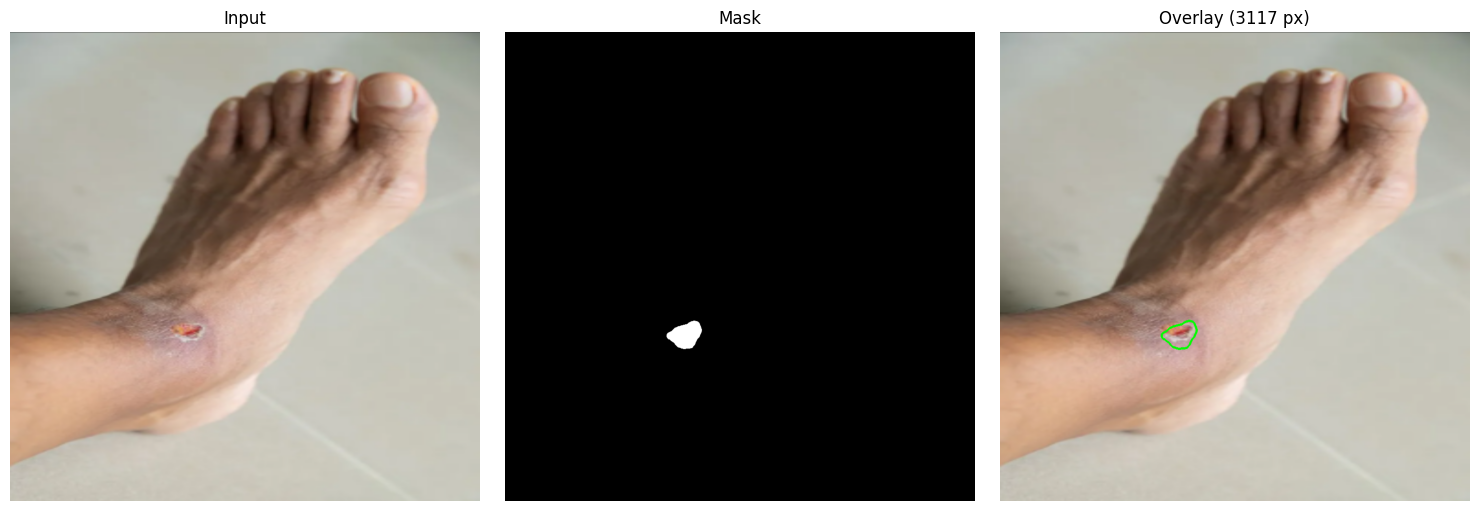

In [ ]:
orig = load_image_rgb(infer_paths[0])
pred = segment_wound(orig, detector, medsam, DEVICE)

img_show = cv2.resize(orig, (1024, 1024))
contours, _ = cv2.findContours(pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = img_show.copy()
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_show);           axes[0].set_title('Input')
axes[1].imshow(pred, cmap='gray');  axes[1].set_title('Mask')
axes[2].imshow(overlay);            axes[2].set_title(f'Overlay ({pred.sum()} px)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

  YOLO conf=0.648 bbox=[396 260 630 559]


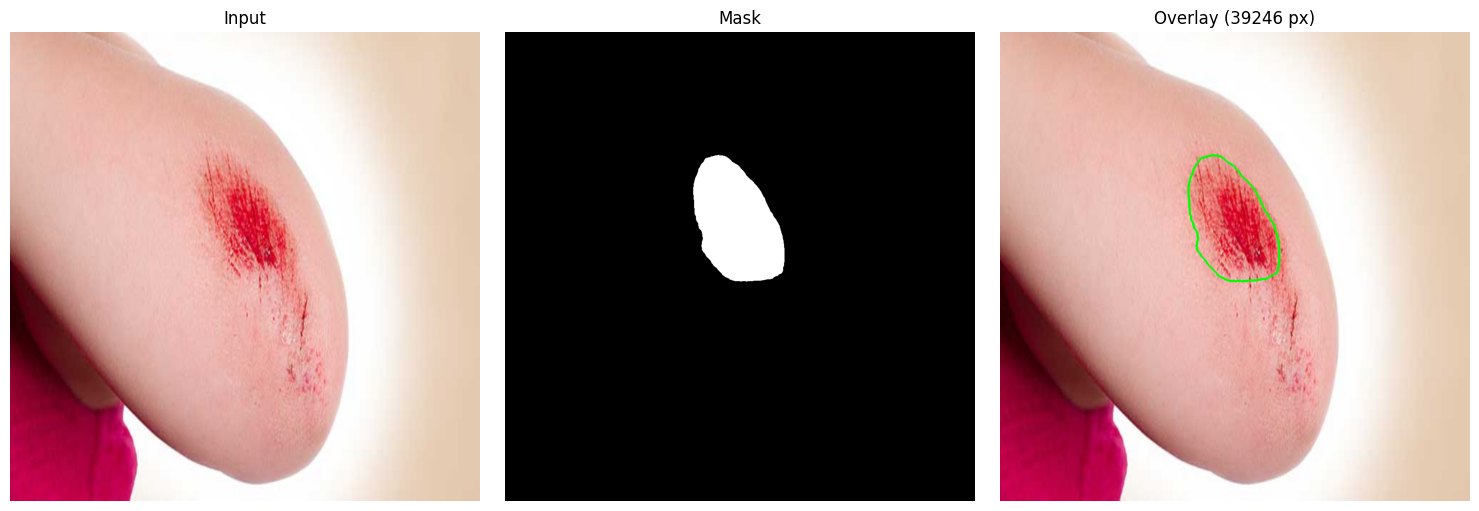

In [ ]:
# Load specific image by name
orig = load_image_rgb('/content/drive/MyDrive/wound_project/data/images/woundtst.jpg')
pred = segment_wound(orig, detector, medsam, DEVICE)

img_show = cv2.resize(orig, (1024, 1024))
contours, _ = cv2.findContours(pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = img_show.copy()
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_show);           axes[0].set_title('Input')
axes[1].imshow(pred, cmap='gray');  axes[1].set_title('Mask')
axes[2].imshow(overlay);            axes[2].set_title(f'Overlay ({pred.sum()} px)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

  YOLO conf=0.420 bbox=[335 610 449 699]


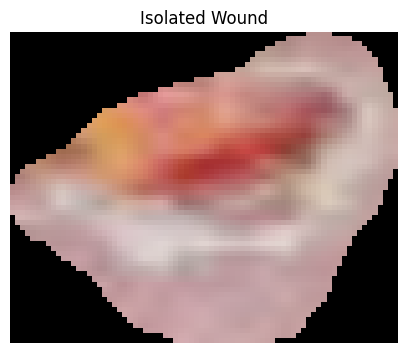

In [ ]:
def extract_wound(img_rgb, mask):
    """Crop and isolate wound region from background"""
    img_1024 = cv2.resize(img_rgb, (1024, 1024))

    # Find bounding box of mask
    coords = np.where(mask > 0)
    y1, y2 = coords[0].min(), coords[0].max()
    x1, x2 = coords[1].min(), coords[1].max()

    # Crop to wound region
    cropped_img  = img_1024[y1:y2, x1:x2]
    cropped_mask = mask[y1:y2, x1:x2]

    # Remove background — set non-wound pixels to black
    result = cropped_img.copy()
    result[cropped_mask == 0] = 0

    return result

# Test it
orig = load_image_rgb(infer_paths[0])
pred = segment_wound(orig, detector, medsam, DEVICE)
wound_crop = extract_wound(orig, pred)

plt.figure(figsize=(5,5))
plt.imshow(wound_crop)
plt.axis('off')
plt.title('Isolated Wound')
plt.show()

In [ ]:
import pandas as pd
import os

OUTPUT_DIR = '/content/drive/MyDrive/wound_project/outputs/final'
os.makedirs(f'{OUTPUT_DIR}/masks',    exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/overlays', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/crops',    exist_ok=True)

records = []

for img_path in infer_paths:
    img_id = img_path.stem
    orig   = load_image_rgb(img_path)

    # Run pipeline
    pred = segment_wound(orig, detector, medsam, DEVICE)

    # 1. Save mask
    cv2.imwrite(f"{OUTPUT_DIR}/masks/{img_id}_mask.png", pred * 255)

    # 2. Save overlay
    img_show = cv2.resize(orig, (1024, 1024))
    contours, _ = cv2.findContours(pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    overlay = img_show.copy()
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 3)
    cv2.imwrite(f"{OUTPUT_DIR}/overlays/{img_id}_overlay.png",
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    # 3. Save isolated crop
    wound_crop = extract_wound(orig, pred)
    cv2.imwrite(f"{OUTPUT_DIR}/crops/{img_id}_crop.png",
                cv2.cvtColor(wound_crop, cv2.COLOR_RGB2BGR))

    # 4. Record area
    area_px  = int(pred.sum())
    area_mm2 = round(area_px / (10 ** 2), 1)
    records.append({'image_id': img_id, 'area_px': area_px, 'area_mm2': area_mm2})
    print(f"✅ {img_id} — {area_px} px")

# Save CSV
pd.DataFrame(records).to_csv(f"{OUTPUT_DIR}/results.csv", index=False)
print("\n🎉 All done! Outputs saved to Drive")

  YOLO conf=0.420 bbox=[335 610 449 699]
✅ wound — 3117 px

🎉 All done! Outputs saved to Drive
